In [1]:
!pip install prophet

In [2]:
import os
import pandas as pd
import numpy as np
import math
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import keras
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.layers import Dense, LSTM, LeakyReLU, Dropout
from prophet import Prophet

In [ ]:
datas=pd.read_csv('/content/BTC-USD_data.csv')
datas=pd.read_csv('/content/LTC-USD_data.csv')
datas=pd.read_csv('/content/ETH-USD_data.csv')

In [ ]:
datas.describe()
datas=datas.sort_values('Date')
datas.shape
datas.head()
datas.tail()


,Date,Open,High,Low,Close,Volume
1822,2024-12-27,3331.053711,3436.710693,3302.575684,3328.916992,24091627403
1823,2024-12-28,3328.774658,3419.920166,3318.033936,3397.902344,14305648523
1824,2024-12-29,3397.862549,3406.648438,3321.664795,3349.513428,13440907792
1825,2024-12-30,3349.585938,3428.527344,3298.804443,3356.392578,26981583962
1826,2024-12-31,3356.394775,3444.396729,3311.412598,3332.531738,20845452085


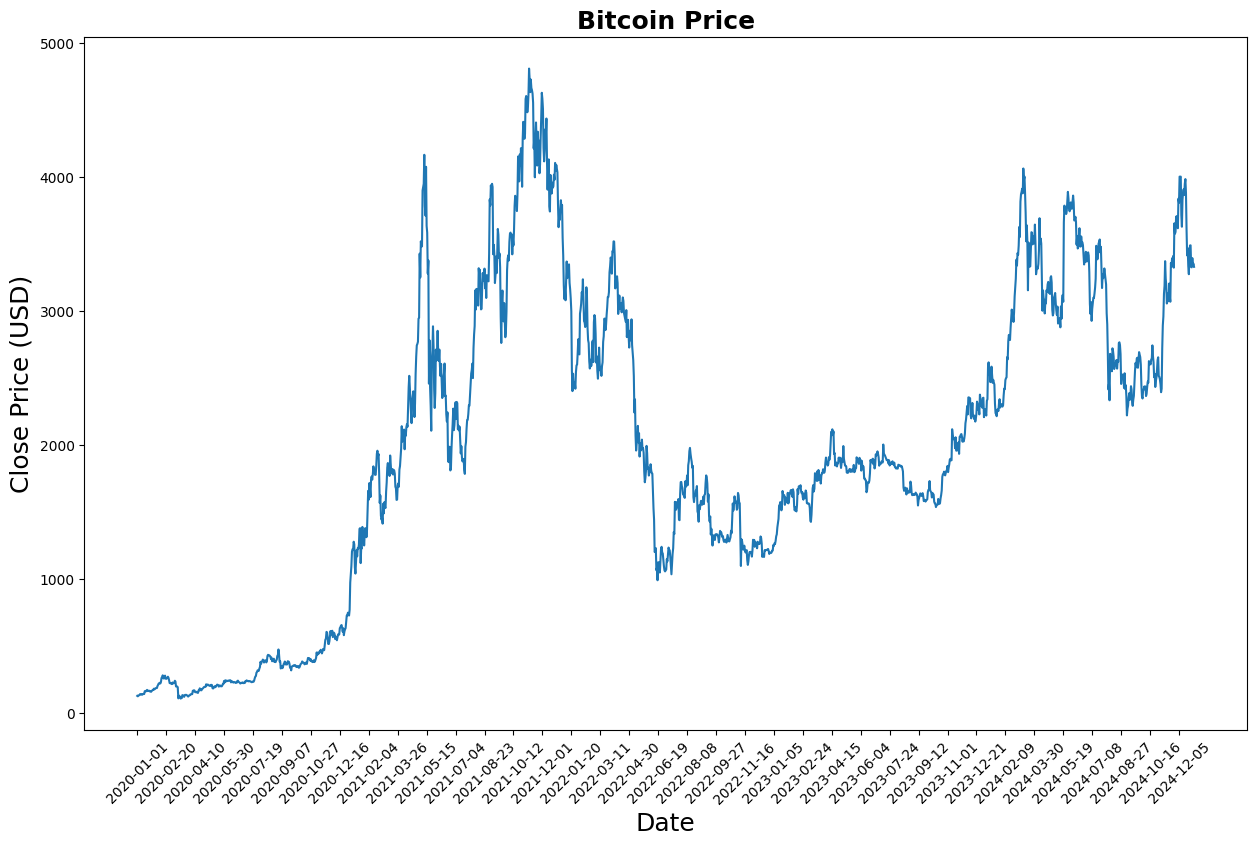

real: [130.80200195], normalized:[0.00429569]
real: [3638.12207031], normalized:[0.75029885]
real: [1127.65649414], normalized:[0.21632556]


In [ ]:
#Creating a dataframe for Closing Price (USD) column as it's our target variable to predict.
price= datas[['Close']]
plt.figure(figsize = (15,9))
plt.plot(price)
plt.xticks (range(0, datas.shape[0],50), datas[ 'Date'].loc[::50], rotation=45)
plt.title("Bitcoin Price", fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price (USD)', fontsize=18)
plt.show()

required_features = ['Open', 'High', 'Low','Volume']
output_label = 'Close'
min_max_scaler = MinMaxScaler() #this by default returns the value between 0-10.
norm_data = min_max_scaler.fit_transform(price.values) #fitting these values
norm_data
print(f'real: {price.values[0]}, normalized:{norm_data[0]}')
print(f'real: {price.values[500]}, normalized:{norm_data[500]}')
print(f'real: {price.values[900]}, normalized:{norm_data[900]}')

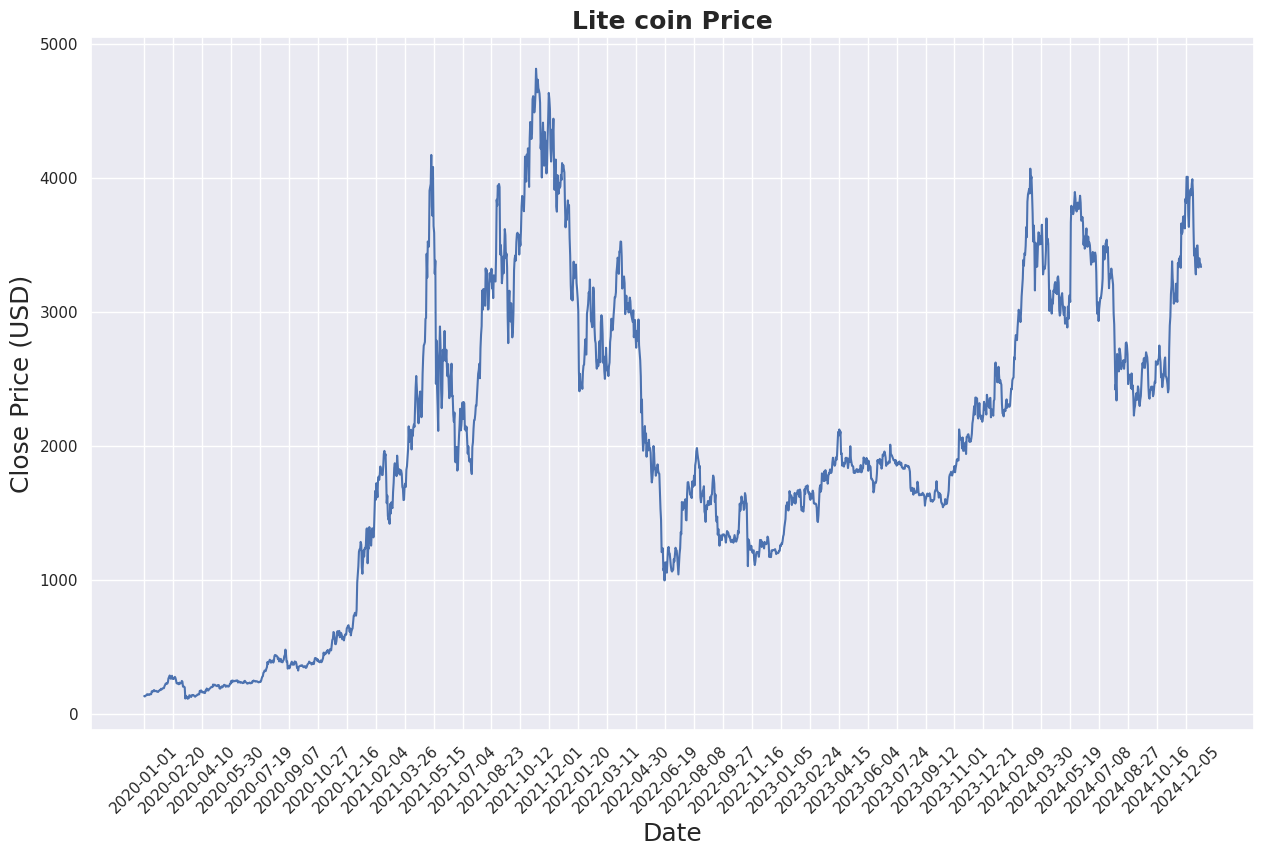

In [ ]:
#Creating a dataframe for Closing Price (USD) column as it's our target variable to predict.
price= datas[['Close']]
plt.figure(figsize = (15,9))
plt.plot(price)
plt.xticks (range(0, datas.shape[0],50), datas[ 'Date'].loc[::50], rotation=45)
plt.title("Lite coin Price", fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price (USD)', fontsize=18)
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
datas[required_features],
datas[output_label],
test_size = 0.3
)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
future_set = datas.shift(periods=40).tail(40)

Text(0, 0.5, '$ Price')

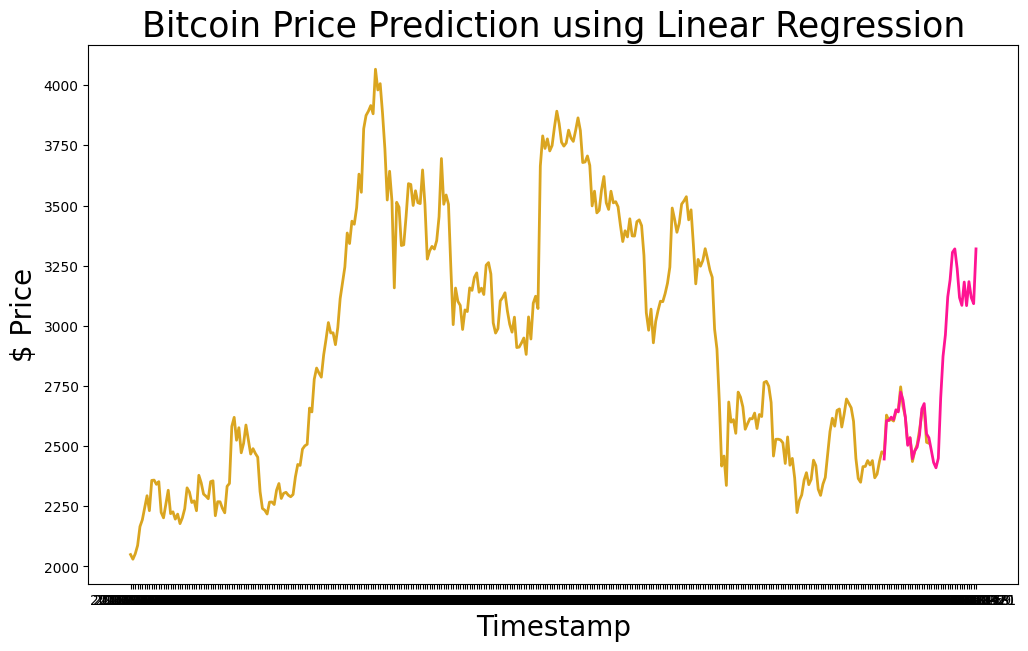

In [ ]:
prediction = model.predict(future_set[required_features])
plt.figure(figsize = (12, 7))
plt.plot(datas["Date"][-400:-60], datas["Close"][-400:-60], color='goldenrod', lw=2)
plt.plot(future_set["Date"], prediction, color='deeppink', lw=2)
plt.title("Bitcoin Price Prediction using Linear Regression", size=25)
plt.xlabel("Timestamp", size=20)
plt.ylabel("$ Price", size=20)

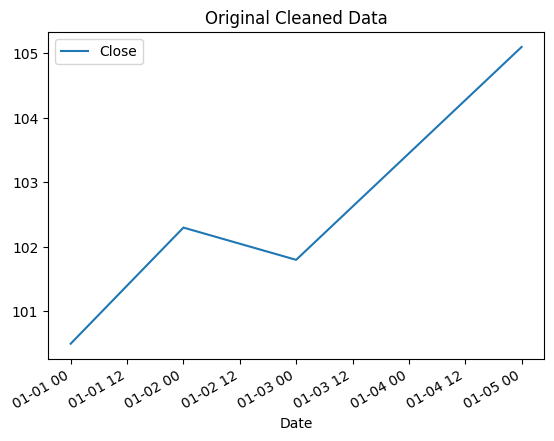

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdopbznv6/ked3v4jr.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdopbznv6/js0_da7f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=39063', 'data', 'file=/tmp/tmpdopbznv6/ked3v4jr.json', 'init=/tmp/tmpdopbznv6/js0_da7f.json', 'output', 'file=/tmp/tmpdopbznv6/prophet_modelv82biwde/prophet_model-20250929040735.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:07:35 - cmdstanpy - INFO - Chain [1] start processing
IN

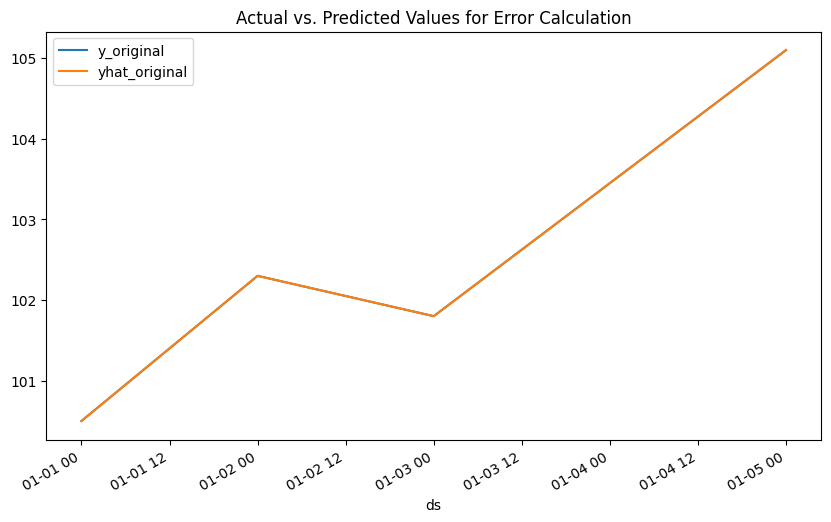

Absolute Error Statistics:
count    4.000000
mean     0.000233
std      0.000009
min      0.000223
25%      0.000229
50%      0.000232
75%      0.000236
max      0.000245
dtype: float64

Mean Squared Error (MSE): 5.4329774281253325e-08
Mean Absolute Error (MAE): 0.00023296271757899945


In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assuming 'datas' is your original DataFrame with 'Date' and 'Close' columns ---
# For demonstration, this is a sample DataFrame that would cause the error:
# It includes a non-numeric value ('oops') and a missing value (NaN)
datas = pd.DataFrame({
    'Date': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06']),
    'Close': [100.5, 102.3, 101.8, 'oops', 105.1, np.nan]
})

# --- DATA CLEANING STEP (FIX) ---
# Convert the 'Close' column to a numeric type. This turns non-numeric entries into NaN.
datas['Close'] = pd.to_numeric(datas['Close'], errors='coerce')

# Drop any rows where 'Close' is NaN to ensure only valid data is used.
datas.dropna(subset=['Close'], inplace=True)
# ---------------------------------

# Set up plotting style
color = sns.color_palette()
%matplotlib inline

# Reverse the DataFrame order for plotting and analysis
df = datas.iloc[::-1]

# Plot the cleaned data
df.plot(x='Date', y='Close')
plt.title('Original Cleaned Data')
plt.show()

# Prepare data for Prophet: rename columns and apply log transformation
ml_df = df.reset_index(drop=True).rename(columns={'Date':'ds', 'Close':'y'})
ml_df['y'] = np.log(ml_df['y'])

# Initialize and fit the Prophet model
model = Prophet()
model.fit(ml_df)

# Create a future DataFrame for forecasting
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

# Join the forecast and original data
two_years = forecast.set_index('ds').join(ml_df.set_index('ds'))

# Transform 'y' and 'yhat' back to the original scale
two_years['y_original'] = two_years['y'].apply(lambda x: np.exp(x) if pd.notnull(x) else np.nan)
two_years['yhat_original'] = np.exp(two_years.yhat)
two_years['yhat_upper_original'] = np.exp(two_years.yhat_upper)
two_years['yhat_lower_original'] = np.exp(two_years.yhat_lower)

# Filter data for error calculation to include only dates with actual 'y_original' values
two_years_error_calc = two_years[two_years['y_original'].notnull()]
if len(two_years_error_calc) > 800:
    two_years_error_calc = two_years_error_calc.tail(800)

# Plot the actual vs. predicted values
two_years_error_calc[['y_original', 'yhat_original']].plot(figsize=(10, 6))
plt.title('Actual vs. Predicted Values for Error Calculation')
plt.show()

# Calculate and display descriptive statistics of the absolute error
two_years_AE = (two_years_error_calc.yhat_original - two_years_error_calc.y_original)
print("Absolute Error Statistics:")
print(two_years_AE.describe())

# Calculate and print error metrics
mse = mean_squared_error(two_years_error_calc.y_original, two_years_error_calc.yhat_original)
mae = mean_absolute_error(two_years_error_calc.y_original, two_years_error_calc.yhat_original)

print(f"\nMean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")

/tmp/ipython-input-2189400425.py:6: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(future_set["Date"], prediction, color='deeppink', lw=2)


Text(0, 0.5, '$ Price')

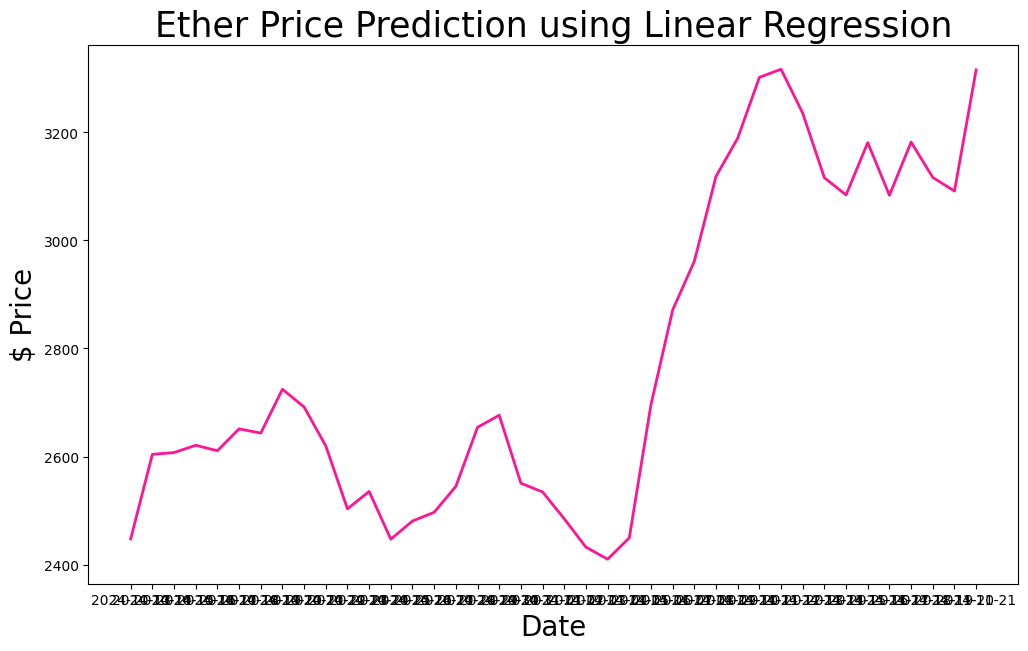

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
prediction = model.predict(future_set[required_features])
plt.figure(figsize = (12, 7))
plt.plot(datas["Date"][-400:-60], datas["Close"][-400:-60], color='goldenrod', lw=2)
plt.plot(future_set["Date"], prediction, color='deeppink', lw=2)
plt.title("Ether Price Prediction using Linear Regression", size=25)
plt.xlabel("Date", size=20)
plt.ylabel("$ Price", size=20)

In [ ]:
def univariate_data(dataset, start_index, end_index, history_size, target_size):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i)
    # Reshape data from (history size,) to (history_size, 1)
    data.append(np.reshape(dataset[indices], (history_size, 1)))
    labels.append(dataset[i+target_size])
  return np.array(data), np.array(labels)

past_history=5 #using 5 days of data to learn to predict the next point in the time series 'future_target'
future_target=0
TRAIN_SPLIT=int(len(norm_data)*0.8)

# Prepare training data
x_train, y_train = univariate_data(norm_data, 0, TRAIN_SPLIT, past_history, future_target)

# Prepare testing data
x_test, y_test = univariate_data(norm_data, TRAIN_SPLIT, None, past_history, future_target)

print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (1456, 5, 1)
Shape of y_train: (1456, 1)
Shape of x_test: (361, 5, 1)
Shape of y_test: (361, 1)


In [ ]:
# Parameters
num_units= 64 # Number of neurons
learning_rate = 0.0001
activation_function = 'sigmoid' # This is not used in the corrected model architecture
loss_function = 'mse'
batch_size = 5
num_epochs = 250

# Initialize the Adam optimizer with the correct argument name
adam = Adam(learning_rate=learning_rate)

# Initialize the RNN model
model= Sequential()
model.add(LSTM(units= num_units, input_shape=(None, 1)))
model.add(LeakyReLU(alpha =0.5))
model.add(Dropout(0.1))
model.add(Dense(units = 1))

# Compile the model with the corrected optimizer
model.compile(optimizer=adam, loss=loss_function)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0277 - val_loss: 8.7276e-04
Epoch 2/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0186 - val_loss: 5.6470e-04
Epoch 3/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0104 - val_loss: 4.2211e-04
Epoch 4/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - val_loss: 3.7054e-04
Epoch 5/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0036 - val_loss: 3.1374e-04
Epoch 6/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023 - val_loss: 2.5548e-04
Epoch 7/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019 - val_loss: 2.1795e-04
Epoch 8/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0018 - val_loss: 2.1467e-04
Epoch 9/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0016 - val_loss: 2.0826e-04
Epoch 10/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - val_loss: 2.1033e-04
Epoch 11/250
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0014 - val_loss: 2.0641e-

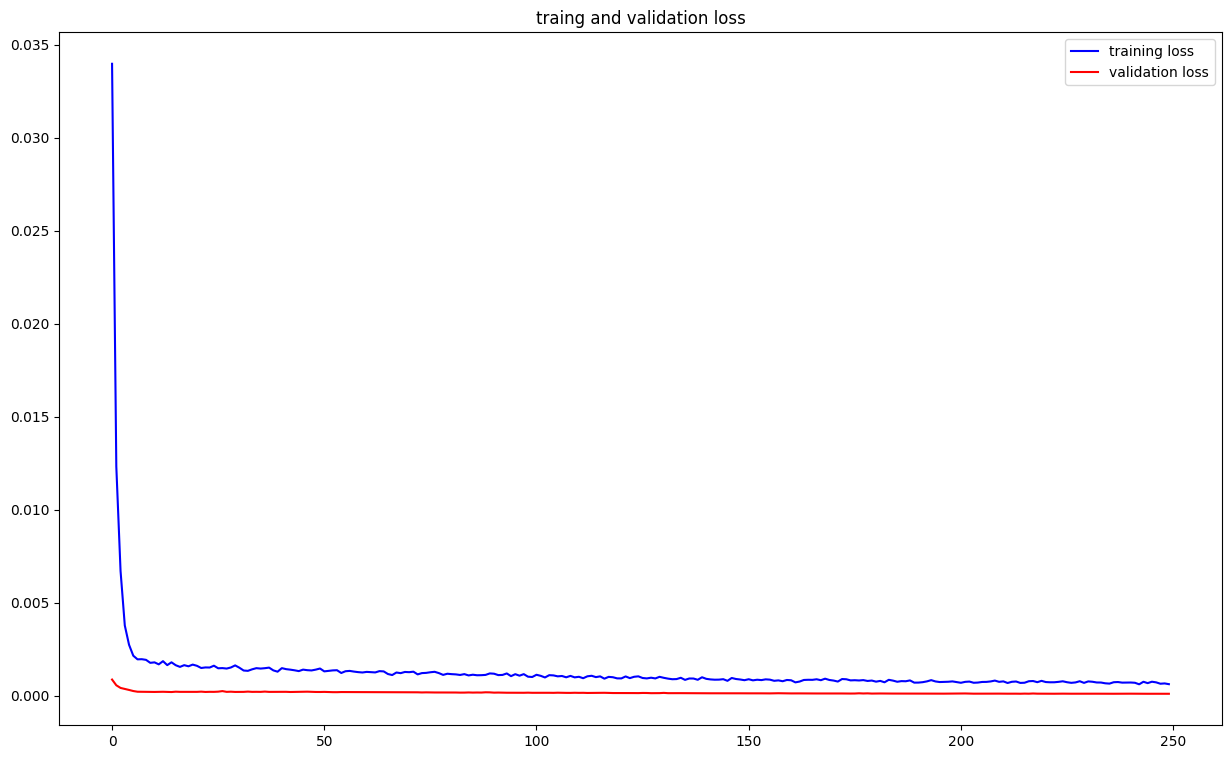

In [ ]:
#using training set to train the model
history= model.fit(
 x_train,
 y_train,
 validation_split =0.1,
 batch_size=batch_size,
 epochs=num_epochs,
 shuffle =False
)
loss=history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
plt.figure(figsize=(15,9))
plt.plot(epochs,loss,'b',label='training loss')
plt.plot(epochs,val_loss,'r',label='validation loss')
plt.title("traing and validation loss")
plt.legend()
plt.show
a=min_max_scaler.inverse_transform(y_test)
b=min_max_scaler.inverse_transform(model.predict(x_test))

In [ ]:
original=pd.DataFrame(a)
predictions = pd.DataFrame(b)
sns.set(rc={'figure.figsize':(11.7+2,8.27+2)})
ax = sns.lineplot (x = original.index, y =original[0], label= "Test Data", color ='royalblue')
ax = sns.lineplot(x = predictions.index, y =predictions[0], label="Prediction", color ='tomato')
ax.set_title('Bitcoin price', size =14, fontweight='bold')
ax.set_xlabel("Days", size = 14)
ax.set_ylabel("Cost (USD)", size = 14)
ax.set_xticklabels('',size=10)
from sklearn.metrics import mean_squared_error
from math import sqrt
x = np.array(original[0]).ravel()
y = np.array(predictions[0]).ravel()
rmse = sqrt(mean_squared_error(x, y))
print('RMSE: %.4f' % (rmse*0.0001))

NameError: name 'a' is not defined